C:\Users\Probook\anaconda3\Lib\site-packages\pennylane\__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


OBJECTIVE 2: CLASSICAL OPTIMIZER COMPARISON (FIXED PARAMS)

8-node graph: Optimal cut = 10
10-node graph: Optimal cut = 15


Graph: 8 nodes | Optimizer: COBYLA

  Trial 1/5
    Final cut: 8.37/10
    Approx ratio: 0.8370
    Time: 17.62s
    Iterations: 148
    Success: True

  Trial 2/5
    Final cut: 8.37/10
    Approx ratio: 0.8370
    Time: 18.39s
    Iterations: 148
    Success: True

  Trial 3/5
    Final cut: 8.37/10
    Approx ratio: 0.8370
    Time: 17.91s
    Iterations: 148
    Success: True

  Trial 4/5
    Final cut: 8.37/10
    Approx ratio: 0.8370
    Time: 18.15s
    Iterations: 148
    Success: True

  Trial 5/5
    Final cut: 8.37/10
    Approx ratio: 0.8370
    Time: 18.31s
    Iterations: 148
    Success: True

Graph: 8 nodes | Optimizer: L-BFGS-B

  Trial 1/5
    Final cut: 8.37/10
    Approx ratio: 0.8370
    Time: 4.37s
    Iterations: 60
    Success: True

  Trial 2/5
    Final cut: 8.37/10
    Approx ratio: 0.8370
    Time: 4.27s
    Iterations: 60
    Success:

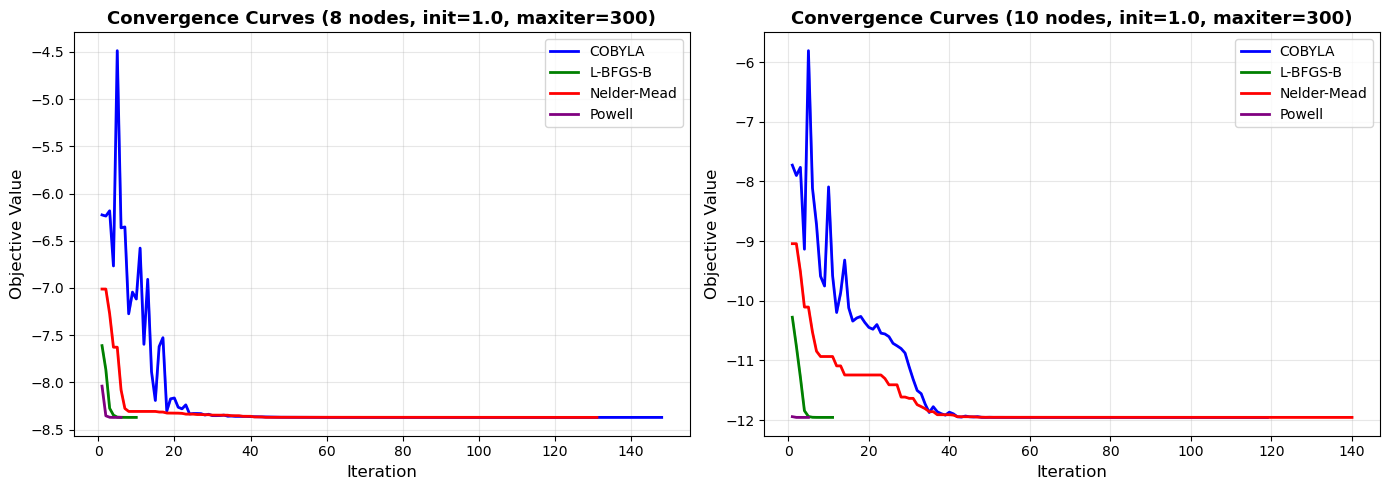


✓ Convergence plots saved as 'objective2_convergence_fixed.png'


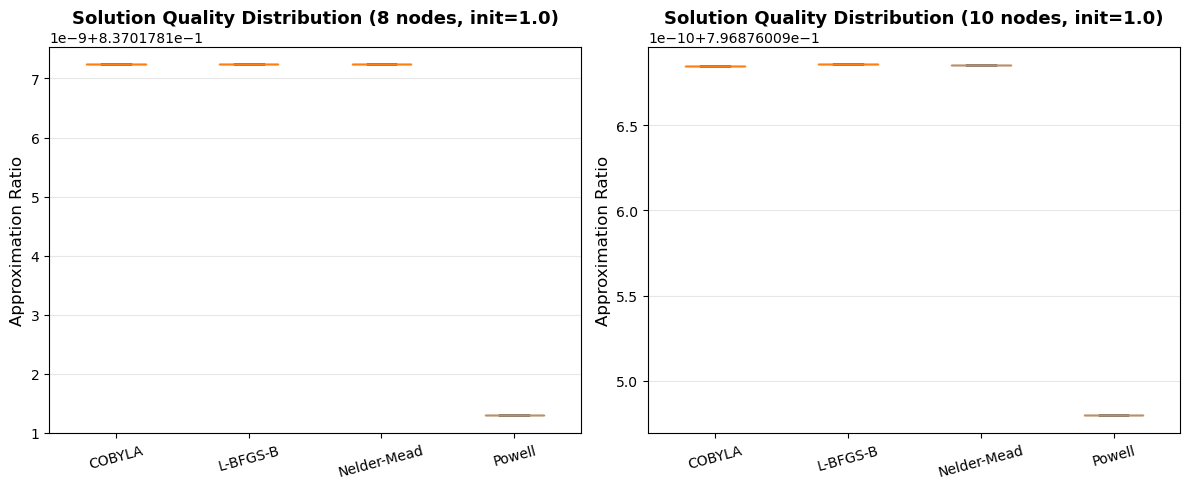

✓ Quality boxplots saved as 'objective2_quality_boxplot_fixed.png'


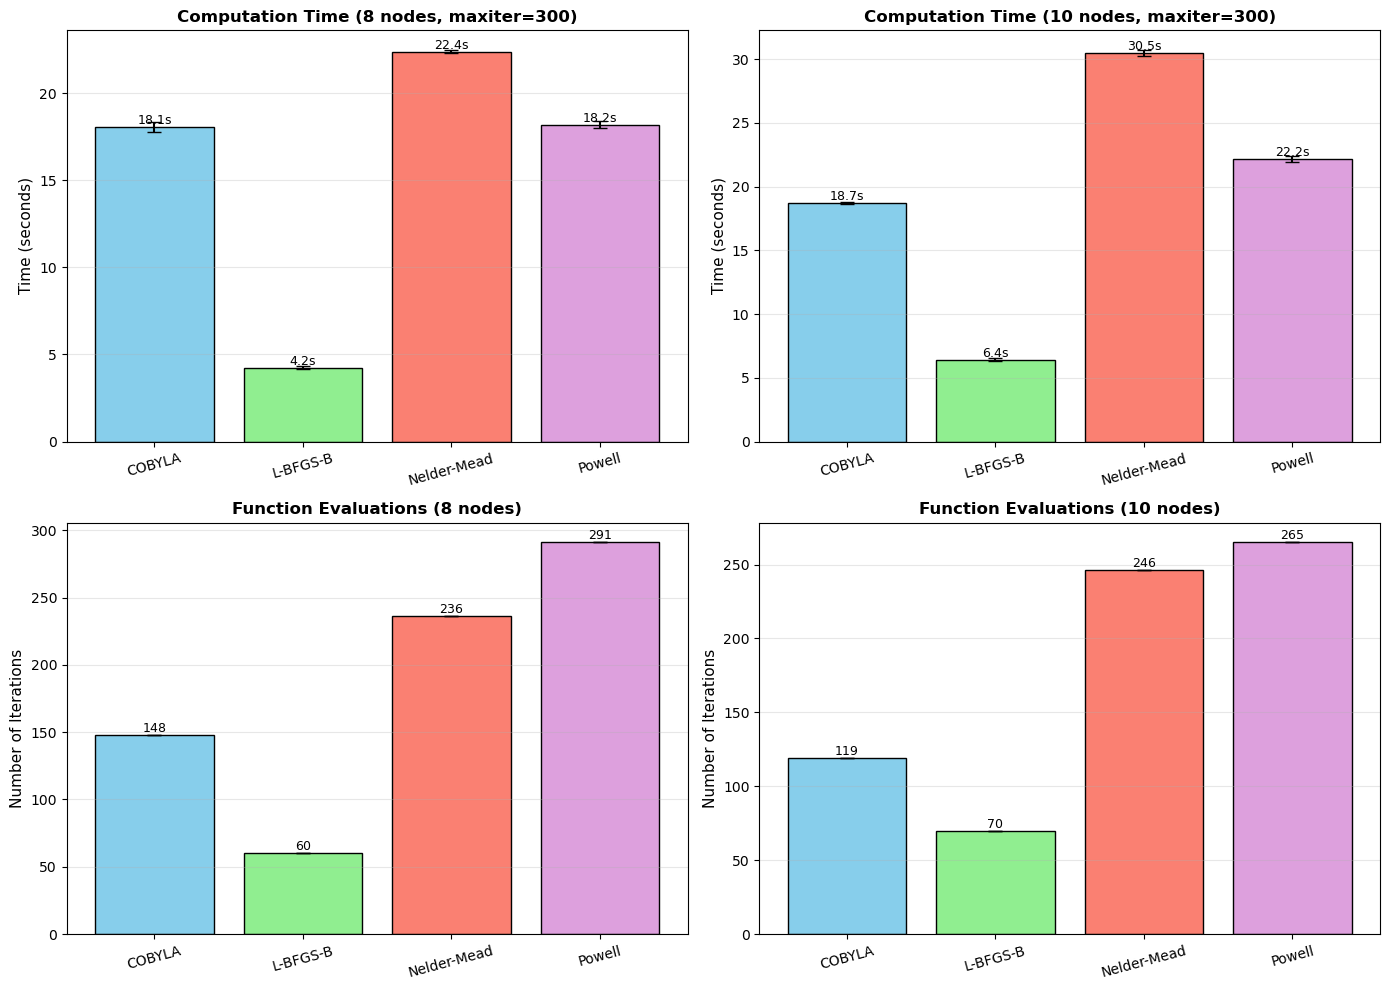

✓ Time/iterations comparison saved as 'objective2_time_iterations_fixed.png'


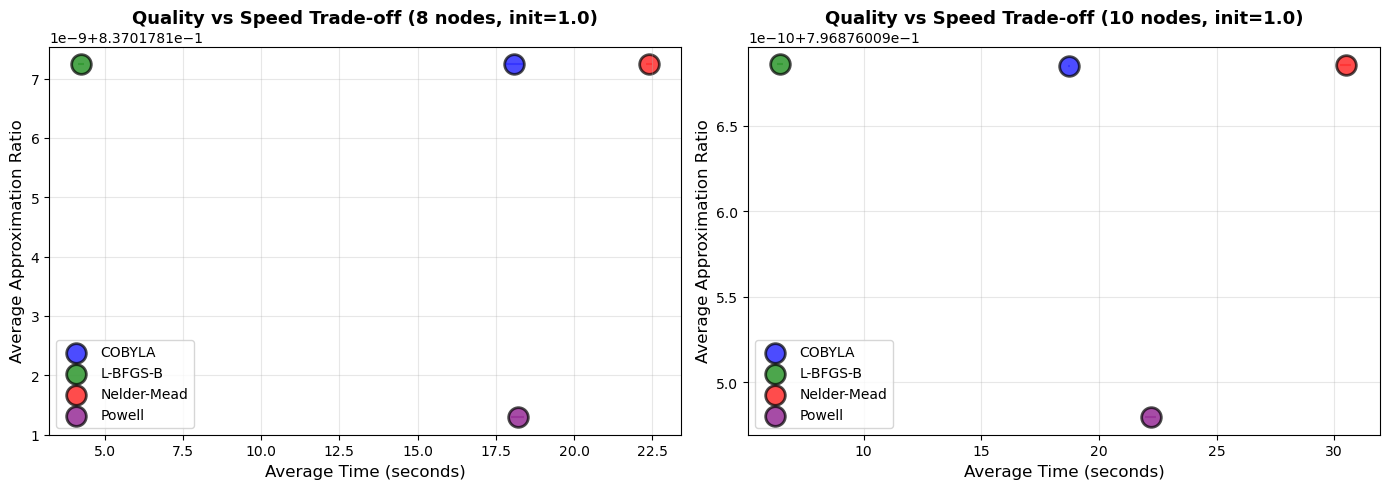

✓ Quality vs speed plot saved as 'objective2_quality_vs_speed_fixed.png'

OBJECTIVE 2 COMPLETE (FIXED INIT=1.0, MAXITER=300)

Key Findings:

8-node graph:
  Best quality: Nelder-Mead (0.8370)
  Fastest: L-BFGS-B (4.24s)
  Fastest convergence: Powell (0 iterations)

10-node graph:
  Best quality: L-BFGS-B (0.7969)
  Fastest: L-BFGS-B (6.43s)
  Fastest convergence: Powell (0 iterations)

Files generated:
  - objective2_convergence_fixed.png
  - objective2_quality_boxplot_fixed.png
  - objective2_time_iterations_fixed.png
  - objective2_quality_vs_speed_fixed.png


In [1]:
import pennylane as qml
from pennylane import numpy as np
from scipy.optimize import minimize
import time
import matplotlib.pyplot as plt
import networkx as nx

np.random.seed(42)

# ============================================================
# DEFINE GRAPHS
# ============================================================

graphs = {
    8: [(0,1), (1,2), (2,3), (3,4), (4,5), (5,6), (6,7), (7,0), 
        (0,2), (1,3), (2,4), (3,5)],
    
    10: [(0,1), (1,2), (2,3), (3,4), (4,5), (5,6), (6,7), (7,8), (8,9), (9,0),
         (0,3), (1,4), (2,5), (3,6), (4,7)]
}

# Compute optimal cuts
def compute_optimal_cut(n_wires, graph):
    best_cut = 0
    for partition in range(2**n_wires):
        bitstring = format(partition, f'0{n_wires}b')
        cut = sum(1 for edge in graph if bitstring[edge[0]] != bitstring[edge[1]])
        best_cut = max(best_cut, cut)
    return best_cut

optimal_cuts = {n: compute_optimal_cut(n, graphs[n]) for n in [8, 10]}

print("="*80)
print("OBJECTIVE 2: CLASSICAL OPTIMIZER COMPARISON (FIXED PARAMS)")
print("="*80)
print(f"\n8-node graph: Optimal cut = {optimal_cuts[8]}")
print(f"10-node graph: Optimal cut = {optimal_cuts[10]}")
print()

# ============================================================
# QAOA FUNCTIONS
# ============================================================

def U_B(beta, n_wires):
    for wire in range(n_wires):
        qml.RX(2 * beta, wires=wire)

def U_C(gamma, graph):
    for edge in graph:
        qml.CNOT(wires=edge)
        qml.RZ(gamma, wires=edge[1])
        qml.CNOT(wires=edge)

# ============================================================
# DEFINE OPTIMIZERS (maxiter=300)
# ============================================================

optimizers = {
    'COBYLA': {
        'method': 'COBYLA',
        'options': {'maxiter': 300, 'rhobeg': 0.5, 'tol': 1e-6}
    },
    'L-BFGS-B': {
        'method': 'L-BFGS-B',
        'options': {'maxiter': 300}
    },
    'Nelder-Mead': {
        'method': 'Nelder-Mead',
        'options': {'maxiter': 300, 'xatol': 1e-6, 'fatol': 1e-6}
    },
    'Powell': {
        'method': 'Powell',
        'options': {'maxiter': 300, 'xtol': 1e-6, 'ftol': 1e-6}
    }
}

# ============================================================
# MAIN EXPERIMENT
# ============================================================

n_layers = 2  # Fixed at p=2
n_trials = 5  # 5 trials per optimizer

results = {}

for n_wires in [8, 10]:
    graph = graphs[n_wires]
    optimal_cut = optimal_cuts[n_wires]
    
    results[n_wires] = {}
    
    # Create device
    dev = qml.device("default.qubit", wires=n_wires)
    
    # Define circuit
    @qml.qnode(dev)
    def circuit(params):
        # Reshape from 1D to 2D
        params_2d = params.reshape(2, n_layers)
        gammas = params_2d[0]
        betas = params_2d[1]
        
        for wire in range(n_wires):
            qml.Hadamard(wires=wire)
        
        for gamma, beta in zip(gammas, betas):
            U_C(gamma, graph)
            U_B(beta, n_wires)
        
        C = qml.sum(*(qml.Z(w1) @ qml.Z(w2) for w1, w2 in graph))
        return qml.expval(C)
    
    def objective(params):
        return -0.5 * (len(graph) - circuit(params))
    
    # Test each optimizer
    for opt_name, opt_config in optimizers.items():
        print(f"\n{'='*60}")
        print(f"Graph: {n_wires} nodes | Optimizer: {opt_name}")
        print(f"{'='*60}")
        
        results[n_wires][opt_name] = []
        
        # Run multiple trials
        for trial in range(n_trials):
            print(f"\n  Trial {trial + 1}/{n_trials}")
            
            # FIXED INITIALIZATION: All parameters = 1.0
            init_params = np.ones(2 * n_layers)
            
            # Track convergence
            convergence_history = {'iteration': [], 'cost': [], 'time': []}
            iteration_count = [0]
            start_time = time.time()
            
            def callback(params):
                iteration_count[0] += 1
                current_time = time.time() - start_time
                cost = objective(params)
                
                convergence_history['iteration'].append(iteration_count[0])
                convergence_history['cost'].append(cost)
                convergence_history['time'].append(current_time)
            
            # Optimize
            opt_start = time.time()
            result = minimize(
                objective,
                init_params,
                method=opt_config['method'],
                callback=callback,
                options=opt_config['options']
            )
            opt_time = time.time() - opt_start
            
            # Final results
            final_cut = -objective(result.x)
            approx_ratio = final_cut / optimal_cut
            
            # Compute convergence speed (iterations to 95% of final)
            target_cost = result.fun * 0.95
            convergence_iter = next(
                (i for i, cost in enumerate(convergence_history['cost']) 
                 if cost <= target_cost), 
                len(convergence_history['cost'])
            )
            
            # Store trial results
            trial_result = {
                'approx_ratio': approx_ratio,
                'final_cut': final_cut,
                'time': opt_time,
                'iterations': result.nfev,
                'convergence_iter': convergence_iter,
                'success': result.success,
                'convergence_history': convergence_history,
                'final_params': result.x
            }
            
            results[n_wires][opt_name].append(trial_result)
            
            print(f"    Final cut: {final_cut:.2f}/{optimal_cut}")
            print(f"    Approx ratio: {approx_ratio:.4f}")
            print(f"    Time: {opt_time:.2f}s")
            print(f"    Iterations: {result.nfev}")
            print(f"    Success: {result.success}")

# ============================================================
# COMPUTE STATISTICS
# ============================================================

print("\n" + "="*80)
print("STATISTICS SUMMARY")
print("="*80)

stats = {}

for n_wires in [8, 10]:
    stats[n_wires] = {}
    
    for opt_name in optimizers.keys():
        trials = results[n_wires][opt_name]
        
        stats[n_wires][opt_name] = {
            'mean_ratio': np.mean([t['approx_ratio'] for t in trials]),
            'std_ratio': np.std([t['approx_ratio'] for t in trials]),
            'mean_time': np.mean([t['time'] for t in trials]),
            'std_time': np.std([t['time'] for t in trials]),
            'mean_iters': np.mean([t['iterations'] for t in trials]),
            'std_iters': np.std([t['iterations'] for t in trials]),
            'mean_conv_iter': np.mean([t['convergence_iter'] for t in trials]),
            'success_rate': sum([t['success'] for t in trials]) / len(trials) * 100
        }

# ============================================================
# RESULTS TABLES
# ============================================================

for n_wires in [8, 10]:
    print(f"\n{n_wires}-node graph (Optimal cut = {optimal_cuts[n_wires]}):")
    print("-"*100)
    print(f"{'Optimizer':<15} {'Avg Ratio':<15} {'Avg Time (s)':<15} "
          f"{'Avg Iters':<15} {'Conv Speed':<15} {'Success %':<12}")
    print("-"*100)
    
    for opt_name in optimizers.keys():
        s = stats[n_wires][opt_name]
        print(f"{opt_name:<15} "
              f"{s['mean_ratio']:.4f}±{s['std_ratio']:.4f}    "
              f"{s['mean_time']:.2f}±{s['std_time']:.2f}        "
              f"{s['mean_iters']:.1f}±{s['std_iters']:.1f}        "
              f"{s['mean_conv_iter']:.1f}           "
              f"{s['success_rate']:.0f}%")
    print("-"*100)

# ============================================================
# VISUALIZATION 1: CONVERGENCE CURVES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, n_wires in enumerate([8, 10]):
    ax = axes[idx]
    
    colors = {'COBYLA': 'blue', 'L-BFGS-B': 'green', 
              'Nelder-Mead': 'red', 'Powell': 'purple'}
    
    for opt_name in optimizers.keys():
        # Average convergence across trials
        all_histories = [t['convergence_history'] for t in results[n_wires][opt_name]]
        
        # Find max iterations
        max_iters = max(len(h['cost']) for h in all_histories)
        
        # Pad histories to same length
        padded_costs = []
        for h in all_histories:
            padded = list(h['cost'])
            if len(padded) < max_iters:
                padded.extend([padded[-1]] * (max_iters - len(padded)))
            padded_costs.append(padded)
        
        # Compute mean and std
        mean_cost = np.mean(padded_costs, axis=0)
        std_cost = np.std(padded_costs, axis=0)
        iterations = range(1, len(mean_cost) + 1)
        
        # Plot
        ax.plot(iterations, mean_cost, label=opt_name, 
                color=colors[opt_name], linewidth=2)
        ax.fill_between(iterations, 
                        mean_cost - std_cost, 
                        mean_cost + std_cost,
                        color=colors[opt_name], alpha=0.2)
    
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Objective Value', fontsize=12)
    ax.set_title(f'Convergence Curves ({n_wires} nodes, init=1.0, maxiter=300)', 
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('objective2_convergence_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Convergence plots saved as 'objective2_convergence_fixed.png'")

# ============================================================
# VISUALIZATION 2: BOX PLOTS - APPROXIMATION RATIO
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, n_wires in enumerate([8, 10]):
    ax = axes[idx]
    
    data = []
    labels = []
    
    for opt_name in optimizers.keys():
        ratios = [t['approx_ratio'] for t in results[n_wires][opt_name]]
        data.append(ratios)
        labels.append(opt_name)
    
    bp = ax.boxplot(data, labels=labels, patch_artist=True)
    
    # Color boxes
    colors = ['lightblue', 'lightgreen', 'lightcoral', 'plum']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_ylabel('Approximation Ratio', fontsize=12)
    ax.set_title(f'Solution Quality Distribution ({n_wires} nodes, init=1.0)', 
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('objective2_quality_boxplot_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Quality boxplots saved as 'objective2_quality_boxplot_fixed.png'")

# ============================================================
# VISUALIZATION 3: BAR CHARTS - TIME & ITERATIONS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, n_wires in enumerate([8, 10]):
    # Time comparison
    ax1 = axes[0, idx]
    opt_names = list(optimizers.keys())
    times = [stats[n_wires][opt]['mean_time'] for opt in opt_names]
    time_stds = [stats[n_wires][opt]['std_time'] for opt in opt_names]
    
    bars1 = ax1.bar(opt_names, times, yerr=time_stds, 
                    color=['skyblue', 'lightgreen', 'salmon', 'plum'],
                    capsize=5, edgecolor='black')
    ax1.set_ylabel('Time (seconds)', fontsize=11)
    ax1.set_title(f'Computation Time ({n_wires} nodes, maxiter=300)', 
                  fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.tick_params(axis='x', rotation=15)
    
    # Add value labels
    for bar, val in zip(bars1, times):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.1f}s', ha='center', va='bottom', fontsize=9)
    
    # Iterations comparison
    ax2 = axes[1, idx]
    iters = [stats[n_wires][opt]['mean_iters'] for opt in opt_names]
    iter_stds = [stats[n_wires][opt]['std_iters'] for opt in opt_names]
    
    bars2 = ax2.bar(opt_names, iters, yerr=iter_stds,
                    color=['skyblue', 'lightgreen', 'salmon', 'plum'],
                    capsize=5, edgecolor='black')
    ax2.set_ylabel('Number of Iterations', fontsize=11)
    ax2.set_title(f'Function Evaluations ({n_wires} nodes)', 
                  fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.tick_params(axis='x', rotation=15)
    
    # Add value labels
    for bar, val in zip(bars2, iters):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(val)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('objective2_time_iterations_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Time/iterations comparison saved as 'objective2_time_iterations_fixed.png'")

# ============================================================
# VISUALIZATION 4: QUALITY VS SPEED SCATTER
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, n_wires in enumerate([8, 10]):
    ax = axes[idx]
    
    colors = {'COBYLA': 'blue', 'L-BFGS-B': 'green', 
              'Nelder-Mead': 'red', 'Powell': 'purple'}
    
    for opt_name in optimizers.keys():
        s = stats[n_wires][opt_name]
        ax.scatter(s['mean_time'], s['mean_ratio'], 
                  s=200, c=colors[opt_name], 
                  label=opt_name, alpha=0.7, edgecolors='black', linewidths=2)
        
        # Error bars
        ax.errorbar(s['mean_time'], s['mean_ratio'],
                   xerr=s['std_time'], yerr=s['std_ratio'],
                   fmt='none', c=colors[opt_name], alpha=0.3)
    
    ax.set_xlabel('Average Time (seconds)', fontsize=12)
    ax.set_ylabel('Average Approximation Ratio', fontsize=12)
    ax.set_title(f'Quality vs Speed Trade-off ({n_wires} nodes, init=1.0)', 
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('objective2_quality_vs_speed_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Quality vs speed plot saved as 'objective2_quality_vs_speed_fixed.png'")

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "="*80)
print("OBJECTIVE 2 COMPLETE (FIXED INIT=1.0, MAXITER=300)")
print("="*80)

print("\nKey Findings:")

for n_wires in [8, 10]:
    print(f"\n{n_wires}-node graph:")
    
    # Best quality
    best_quality = max(optimizers.keys(), 
                      key=lambda opt: stats[n_wires][opt]['mean_ratio'])
    print(f"  Best quality: {best_quality} "
          f"({stats[n_wires][best_quality]['mean_ratio']:.4f})")
    
    # Fastest
    fastest = min(optimizers.keys(), 
                 key=lambda opt: stats[n_wires][opt]['mean_time'])
    print(f"  Fastest: {fastest} "
          f"({stats[n_wires][fastest]['mean_time']:.2f}s)")
    
    # Best convergence
    best_conv = min(optimizers.keys(),
                   key=lambda opt: stats[n_wires][opt]['mean_conv_iter'])
    print(f"  Fastest convergence: {best_conv} "
          f"({stats[n_wires][best_conv]['mean_conv_iter']:.0f} iterations)")

print("\n" + "="*80)
print("Files generated:")
print("  - objective2_convergence_fixed.png")
print("  - objective2_quality_boxplot_fixed.png")
print("  - objective2_time_iterations_fixed.png")
print("  - objective2_quality_vs_speed_fixed.png")
print("="*80)